# 01 EDA and Preprocessing

This notebook is the first step of the poetry knowledge graph project. It loads the Poetry Foundation dataset, standardizes the column names, cleans the poem text, creates basic features, and explores the corpus with tables and inline visualizations.

The purpose of this EDA is not only to describe the dataset, but also to justify later design choices. The knowledge graph depends on poem text, author names, tags, line structure, word counts, and recurring poetic vocabulary. Before extracting symbols and emotions, we need to understand whether the dataset is large enough, whether important fields are missing, and whether there are outliers that may affect NLP processing.


## Imports and Paths

All logic is kept inside this notebook so the workflow is easy to trace. The only output saved in this notebook is the cleaned poem dataset, because later notebooks need it as input. Figures are displayed inline instead of being saved as separate image files.


In [8]:
from pathlib import Path
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'PoetryFoundationData.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
POEMS_CLEAN_PATH = PROCESSED_DIR / 'poems_clean.csv'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## Preprocessing Functions

The raw dataset uses column names such as Title, Poem, Poet, and Tags. The project uses normalized names: title, poem_text, author, and tags.

The cleaning is intentionally gentle. Poetry uses punctuation, spacing, and line breaks as part of its form, so the original poem structure is preserved in poem_text. A second version, clean_text, collapses whitespace for NLP and vectorization.


In [9]:
def load_raw_data(path):
    return pd.read_csv(path)

def standardize_columns(df):
    renamed = df.copy()
    lower_map = {column.lower().strip(): column for column in renamed.columns}
    candidates = {
        'title': ['title', 'poem title', 'name'],
        'poem_text': ['poem', 'poem_text', 'text', 'content'],
        'author': ['poet', 'author', 'writer'],
        'tags': ['tags', 'tag', 'categories'],
    }
    rename_map = {}
    for target, names in candidates.items():
        for name in names:
            if name in lower_map:
                rename_map[lower_map[name]] = target
                break
    renamed = renamed.rename(columns=rename_map)
    for column in ['title', 'poem_text', 'author', 'tags']:
        if column not in renamed.columns:
            renamed[column] = ''
    return renamed[['title', 'author', 'poem_text', 'tags']].copy()

def clean_poem_text(text):
    value = '' if pd.isna(text) else str(text)
    value = value.replace('\r\n', '\n').replace('\r', '\n')
    value = value.replace('\ufffd', "'")
    value = re.sub(r'[ \t]+', ' ', value)
    value = re.sub(r'\n{3,}', '\n\n', value)
    return value.strip()

def normalize_for_nlp(text):
    return re.sub(r'\s+', ' ', clean_poem_text(text)).strip()

def add_basic_features(df):
    prepared = df.copy()
    prepared['title'] = prepared['title'].fillna('').astype(str).map(lambda value: re.sub(r'\s+', ' ', value).strip())
    prepared['author'] = prepared['author'].fillna('').astype(str).map(lambda value: re.sub(r'\s+', ' ', value).strip())
    prepared['tags'] = prepared['tags'].fillna('').astype(str).map(lambda value: re.sub(r'\s+', ' ', value).strip())
    prepared['poem_text'] = prepared['poem_text'].map(clean_poem_text)
    prepared = prepared[prepared['poem_text'].str.len() > 0].reset_index(drop=True)
    prepared['clean_text'] = prepared['poem_text'].map(normalize_for_nlp)
    prepared['token_count'] = prepared['clean_text'].map(lambda value: len(value.split()))
    prepared['line_count'] = prepared['poem_text'].map(lambda value: len([line for line in value.splitlines() if line.strip()]))
    prepared.insert(0, 'poem_id', prepared.index.map(lambda value: f'poem_{value:05d}'))
    return prepared[['poem_id', 'title', 'author', 'poem_text', 'tags', 'clean_text', 'token_count', 'line_count']]

def preprocess_raw_data(raw_path, output_path):
    df = load_raw_data(raw_path)
    df = standardize_columns(df)
    df = add_basic_features(df)
    df.to_csv(output_path, index=False)
    return df

## EDA Helper Functions

The following functions create summary tables and visualizations. The plots use plt.show() so they appear directly in the notebook report. This keeps the EDA readable in one place and avoids scattering separate image files across the project folder.


In [10]:
def split_tags(tags):
    values = []
    for tag_value in tags.fillna('').astype(str):
        for tag in tag_value.replace(';', ',').split(','):
            cleaned = tag.strip()
            if cleaned and cleaned.lower() != 'nan':
                values.append(cleaned)
    return values

def dataset_overview(df):
    return pd.DataFrame([{
        'number_of_poems': int(len(df)),
        'unique_authors': int(df['author'].nunique()),
        'unique_titles': int(df['title'].nunique()),
        'poems_with_tags': int(df['tags'].fillna('').ne('').sum()),
        'missing_titles': int(df['title'].fillna('').eq('').sum()),
        'missing_authors': int(df['author'].fillna('').eq('').sum()),
        'missing_poem_texts': int(df['poem_text'].fillna('').eq('').sum()),
        'average_poem_length_words': float(df['token_count'].mean()),
        'median_poem_length_words': float(df['token_count'].median()),
        'minimum_poem_length_words': int(df['token_count'].min()),
        'maximum_poem_length_words': int(df['token_count'].max()),
        'average_line_count': float(df['line_count'].mean()),
        'median_line_count': float(df['line_count'].median()),
    }])

def missingness_table(df):
    rows = []
    for column in ['title', 'author', 'poem_text', 'tags', 'clean_text']:
        values = df[column].fillna('').astype(str)
        missing = int(values.eq('').sum())
        rows.append({'column': column, 'missing_count': missing, 'missing_percent': missing / len(df) * 100})
    return pd.DataFrame(rows)

def length_summary_table(df):
    return df[['token_count', 'line_count']].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).reset_index()

def author_summary_table(df):
    counts = df['author'].fillna('').replace('', pd.NA).dropna().value_counts()
    return pd.DataFrame({'metric': ['authors', 'one_poem_authors', 'authors_with_5_or_more_poems', 'authors_with_10_or_more_poems', 'largest_author_poem_count'], 'value': [int(counts.size), int((counts == 1).sum()), int((counts >= 5).sum()), int((counts >= 10).sum()), int(counts.max())]})

def top_authors_table(df, top_n=30):
    counts = df['author'].fillna('').replace('', pd.NA).dropna().value_counts().head(top_n)
    return counts.rename_axis('author').reset_index(name='poem_count')

def top_tags_table(df, top_n=30):
    return pd.DataFrame(Counter(split_tags(df['tags'])).most_common(top_n), columns=['tag', 'count'])

def longest_poems_table(df, top_n=20):
    return df.sort_values('token_count', ascending=False)[['poem_id', 'title', 'author', 'token_count', 'line_count']].head(top_n)

def shortest_poems_table(df, top_n=20):
    return df.sort_values('token_count')[['poem_id', 'title', 'author', 'token_count', 'line_count']].head(top_n)

def top_frequent_terms(df, top_n=30, min_df=5):
    vectorizer = CountVectorizer(stop_words='english', lowercase=True, min_df=min_df, token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b')
    matrix = vectorizer.fit_transform(df['clean_text'].fillna(''))
    counts = matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    return pd.DataFrame(sorted(zip(terms, counts), key=lambda item: item[1], reverse=True)[:top_n], columns=['term', 'count'])

In [11]:
def plot_distribution(series, title, xlabel, bins=40):
    plt.figure(figsize=(10, 6))
    plt.hist(series.dropna(), bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

def plot_bar(counts, title, xlabel):
    labels = [item[0] for item in counts]
    values = [item[1] for item in counts]
    plt.figure(figsize=(12, 7))
    plt.barh(labels[::-1], values[::-1])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()

def plot_boxplot(series, title, ylabel):
    plt.figure(figsize=(8, 6))
    plt.boxplot(series.dropna(), vert=True, showfliers=False)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_scatter(df, x_column, y_column, title, xlabel, ylabel):
    plt.figure(figsize=(10, 6))
    plt.scatter(df[x_column], df[y_column], alpha=0.25, s=12)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_pie(counts, title):
    labels = [item[0] for item in counts]
    values = [item[1] for item in counts]
    plt.figure(figsize=(8, 8))
    plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Load and Clean Data

This step creates the base dataset used by the rest of the project. The cleaned file is saved because later notebooks should not repeat raw-data cleanup. The first rows are displayed to verify that titles, authors, poem text, tags, word counts, and line counts look reasonable.


In [12]:
poems_df = preprocess_raw_data(RAW_DATA_PATH, POEMS_CLEAN_PATH)
poems_df.head()

,poem_id,title,author,poem_text,tags,clean_text,token_count,line_count
0,poem_00000,Objects Used to Prop Open a Window,Michelle Menting,"Dog bone, stapler,\n\ncribbage board, garlic p...",,"Dog bone, stapler, cribbage board, garlic pres...",86,20
1,poem_00001,The New Church,Lucia Cherciu,"The old cupola glinted above the clouds, shone...",,"The old cupola glinted above the clouds, shone...",122,14
2,poem_00002,Look for Me,Ted Kooser,Look for me under the hood\n\nof that old Chev...,,Look for me under the hood of that old Chevrol...,74,12
3,poem_00003,Wild Life,Grace Cavalieri,"Behind the silo, the Mother Rabbit\n\nhunches ...",,"Behind the silo, the Mother Rabbit hunches lik...",166,27
4,poem_00004,Umbrella,Connie Wanek,When I push your button\n\nyou fly off the han...,,When I push your button you fly off the handle...,116,28


## Dataset Overview and Missing Values

The overview table gives the main size and quality indicators. Missingness is especially important here because the app needs poem text for extraction, author names for author search, and tags for weak similarity-pair creation.


In [13]:
display(dataset_overview(poems_df))
display(missingness_table(poems_df))

,number_of_poems,unique_authors,unique_titles,poems_with_tags,missing_titles,missing_authors,missing_poem_texts,average_poem_length_words,median_poem_length_words,minimum_poem_length_words,maximum_poem_length_words,average_line_count,median_line_count
0,13753,3100,13142,12857,0,0,0,251.691922,154.0,1,15713,25.955428,16.0


,column,missing_count,missing_percent
0,title,0,0.000000
1,author,0,0.000000
2,poem_text,0,0.000000
3,tags,896,6.514942
4,clean_text,0,0.000000


## Poem Length Exploration

Poem length affects processing time and relation extraction. Very long poems can produce many symbol and emotion occurrences, while very short poems may have too little context to form relations. The capped plot makes the main distribution easier to read when a few poems are extreme outliers.


,index,token_count,line_count
0,count,13753.000000,13753.000000
1,mean,251.691922,25.955428
2,std,442.509576,46.838891
3,min,1.000000,1.000000
4,10%,60.000000,1.000000
5,25%,99.000000,1.000000
6,50%,154.000000,16.000000
7,75%,264.000000,32.000000
8,90%,465.800000,56.000000
9,95%,696.000000,84.000000


,poem_id,title,author,token_count,line_count
11039,poem_11039,Sunday Morning,Wallace Stevens,1,1
3604,poem_03604,The House,Warsan Shire,1,1
10213,poem_10213,A Poem for Children with Thoughts on Death,Jupiter Hammon,1,1
4242,poem_04242,from The Indigo Glass in the Grass,Wallace Stevens,1,1
1758,poem_01758,"from Don Juan: Canto 1, Stanzas 47-48",Lord Byron (George Gordon),1,1
11929,poem_11929,Call as You Will,Todd Boss,1,1
1759,poem_01759,"from Don Juan: Canto 1, Stanzas 217-221",Lord Byron (George Gordon),1,1
6194,poem_06194,Manatu,Dan Taulapapa McMullin,2,1
11956,poem_11956,Two Poems from “The Day”,Kenneth Goldsmith,2,1
5745,poem_05745,From “Middle Passage”,Darrel Alejandro Holnes,2,1


,poem_id,title,author,token_count,line_count
12980,poem_12980,Song of Myself (1892 version),Walt Whitman,15713,1344
2390,poem_02390,Venus and Adonis,William Shakespeare,9713,1
9270,poem_09270,Scenes of Life at the Capital,Philip Whalen,9451,1336
7302,poem_07302,Paradise Lost: Book 9 (1674 version),John Milton,9047,1172
897,poem_00897,Paradise Lost: Book 10 (1674 version),John Milton,8375,1
891,poem_00891,Paradise Lost: Book 2 (1674 version),John Milton,7959,1
8353,poem_08353,The Glass Essay,Anne Carson,7855,1028
893,poem_00893,Paradise Lost: Book 4 (1674 version),John Milton,7804,1
6976,poem_06976,Absalom and Achitophel,John Dryden,7779,1031
12469,poem_12469,Sohrab and Rustum,Matthew Arnold,7440,885


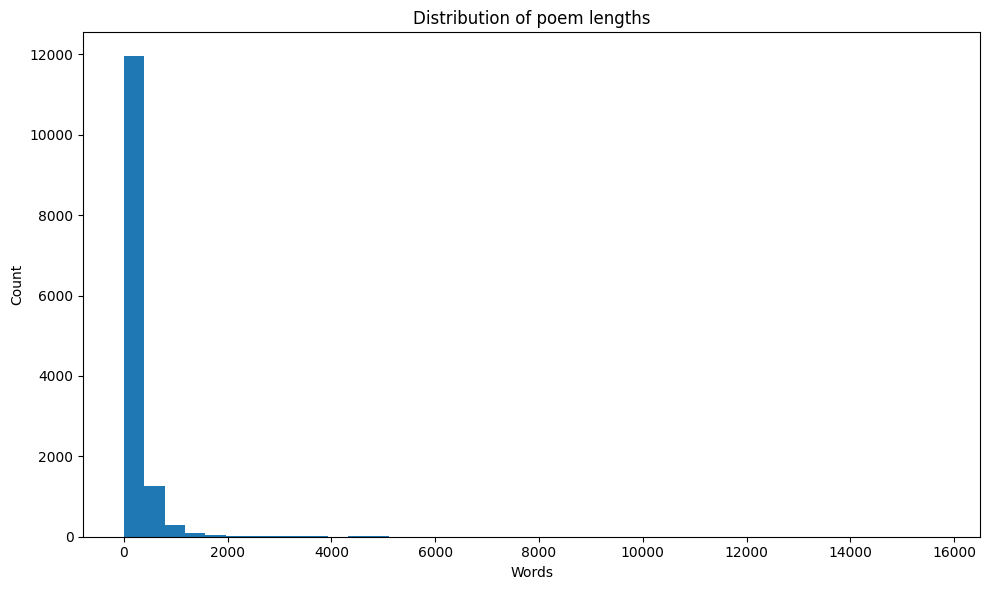

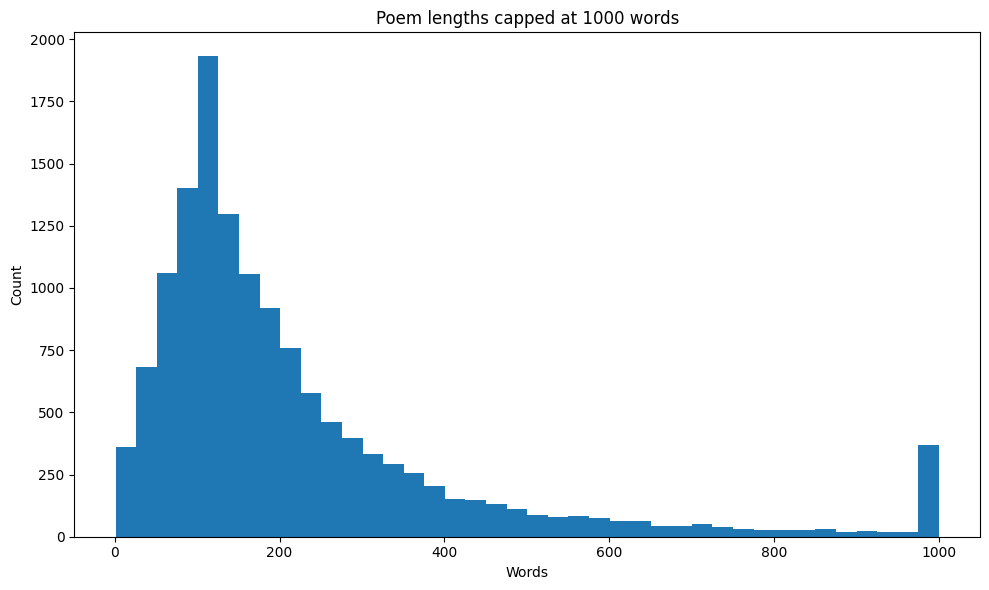

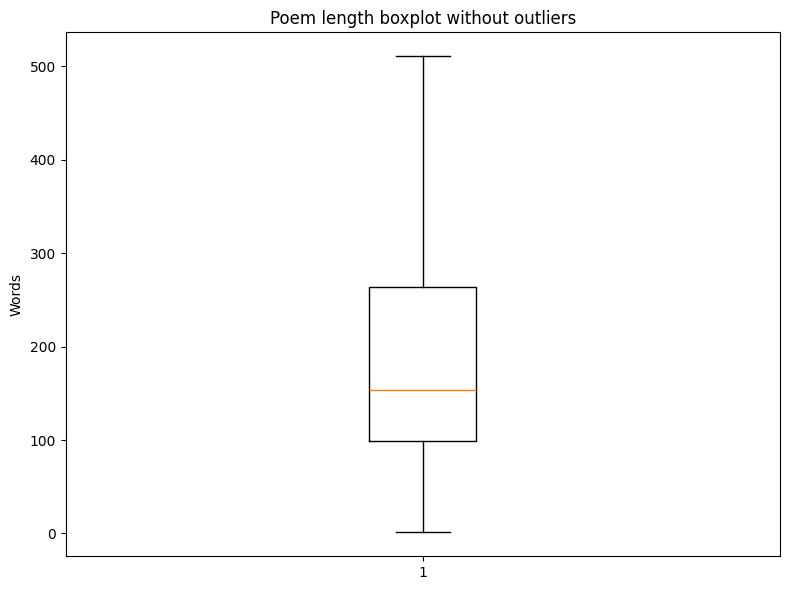

In [14]:
display(length_summary_table(poems_df))
display(shortest_poems_table(poems_df, top_n=10))
display(longest_poems_table(poems_df, top_n=10))
plot_distribution(poems_df['token_count'], 'Distribution of poem lengths', 'Words')
plot_distribution(poems_df['token_count'].clip(upper=1000), 'Poem lengths capped at 1000 words', 'Words')
plot_boxplot(poems_df['token_count'], 'Poem length boxplot without outliers', 'Words')

## Line Count and Structure

The project stores line numbers for symbols and emotion words. Line count exploration helps show why line-aware evidence is useful for poetry, where the same token distance can feel different depending on line breaks.


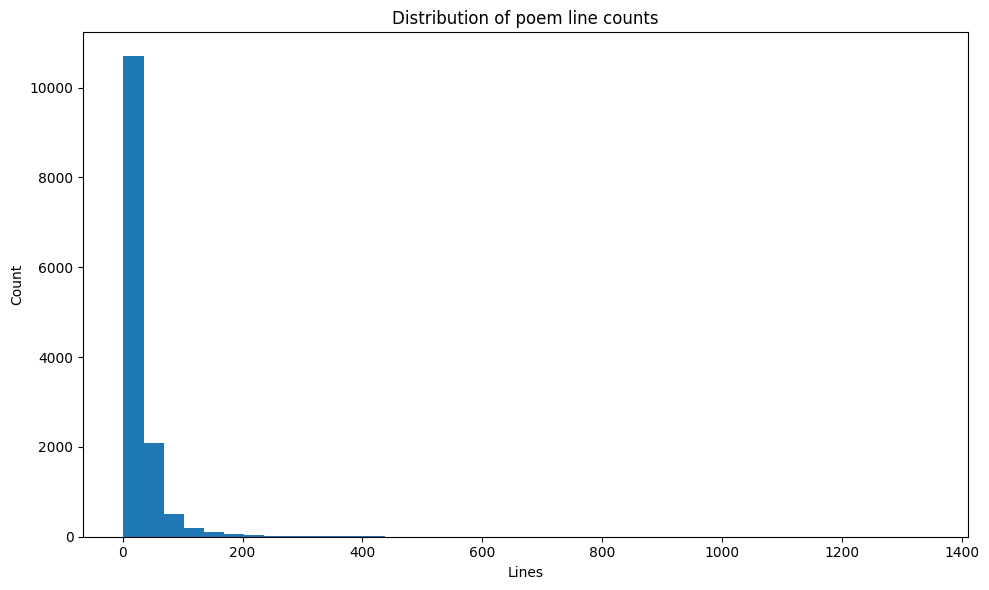

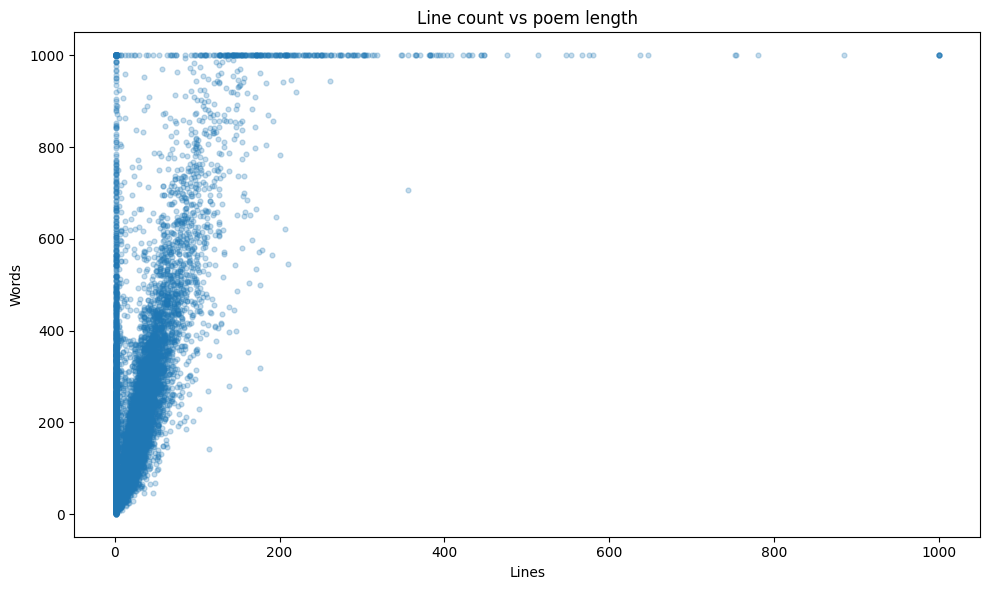

In [15]:
plot_distribution(poems_df['line_count'], 'Distribution of poem line counts', 'Lines')
plot_scatter(poems_df[['token_count', 'line_count']].clip(upper=1000), 'line_count', 'token_count', 'Line count vs poem length', 'Lines', 'Words')

## Author Exploration

Author distribution matters because repeated poems from the same author can influence graph patterns and semantic retrieval pairs. This section checks whether the corpus is broad or dominated by a small number of prolific poets.


,metric,value
0,authors,3100
1,one_poem_authors,1138
2,authors_with_5_or_more_poems,917
3,authors_with_10_or_more_poems,372
4,largest_author_poem_count,85


,author,poem_count
0,William Shakespeare,85
1,"Alfred, Lord Tennyson",73
2,William Wordsworth,51
3,Emily Dickinson,51
4,Rae Armantrout,49
5,Yusef Komunyakaa,42
6,John Ashbery,42
7,William Butler Yeats,41
8,John Donne,38
9,Robert Browning,35


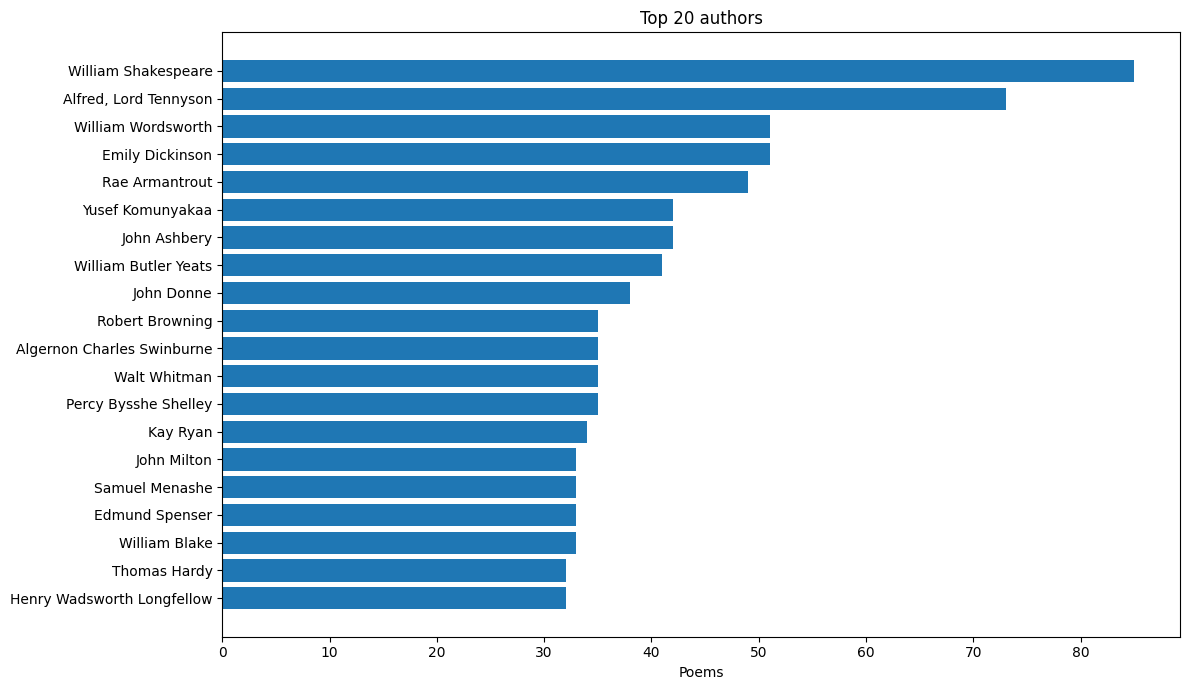

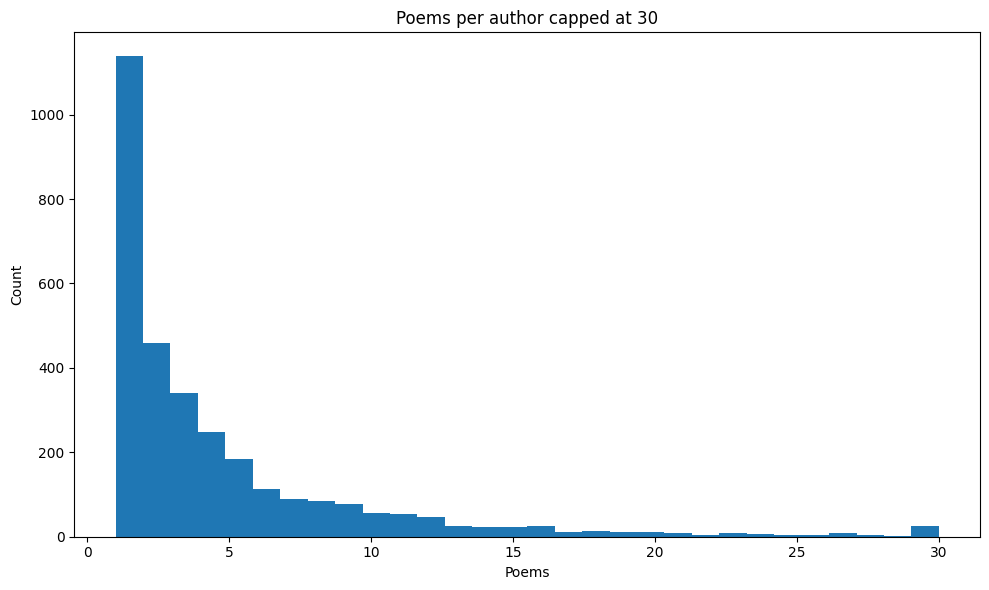

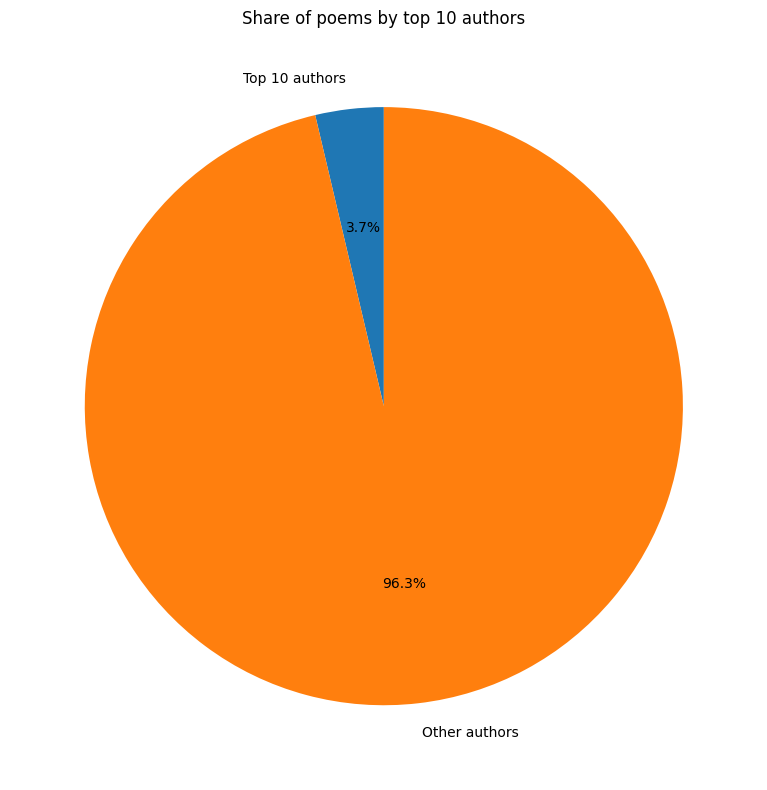

In [16]:
author_counts = poems_df['author'].fillna('').replace('', pd.NA).dropna().value_counts()
display(author_summary_table(poems_df))
display(top_authors_table(poems_df, top_n=25))
plot_bar(list(author_counts.head(20).items()), 'Top 20 authors', 'Poems')
plot_distribution(author_counts.clip(upper=30), 'Poems per author capped at 30', 'Poems', bins=30)
plot_pie([('Top 10 authors', int(author_counts.head(10).sum())), ('Other authors', int(author_counts.iloc[10:].sum()))], 'Share of poems by top 10 authors')

## Tag and Vocabulary Exploration

Tags provide rough themes when available. Frequent terms give a first look at the corpus vocabulary before the more careful symbol extraction in notebook 02. This does not replace symbol extraction; it simply gives an initial sense of common language in the corpus.


,tag,count
0,Living,6223
1,Social Commentaries,4289
2,Relationships,3853
3,Nature,3602
4,Arts & Sciences,3026
5,Love,2123
6,Activities,2100
7,Death,1543
8,Religion,1478
9,Time & Brevity,1466


,term,count
0,like,15185
1,love,6021
2,time,5267
3,man,5060
4,know,4971
5,night,4942
6,day,4862
7,light,4631
8,life,4338
9,said,4222


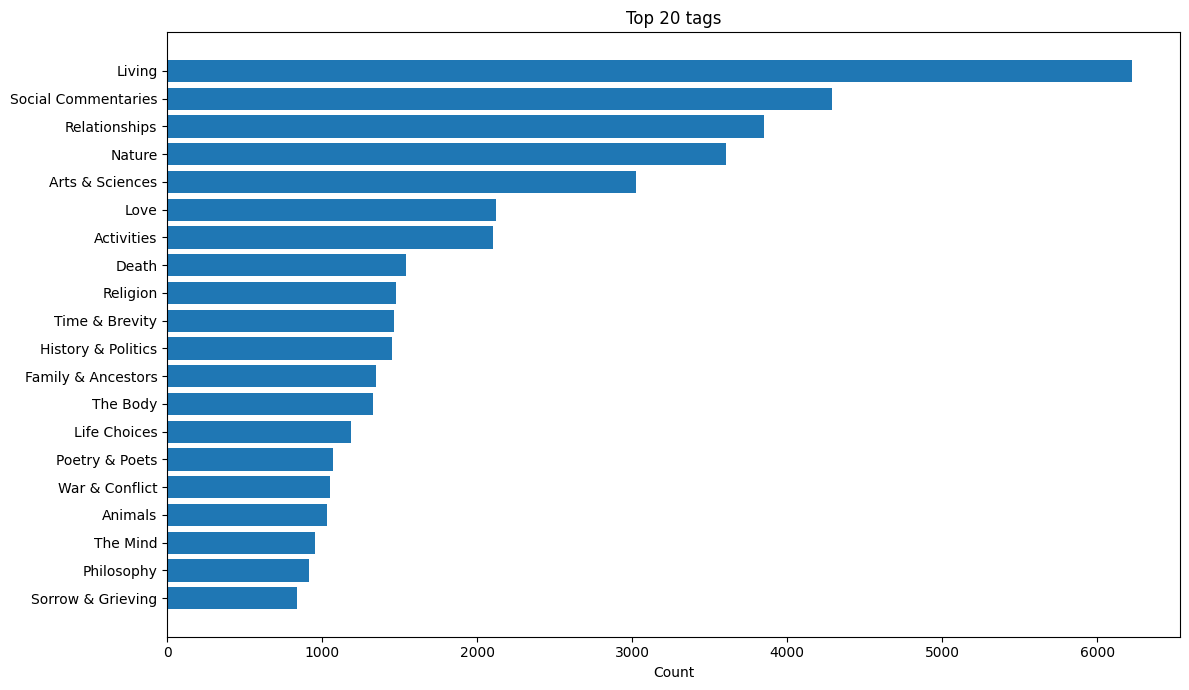

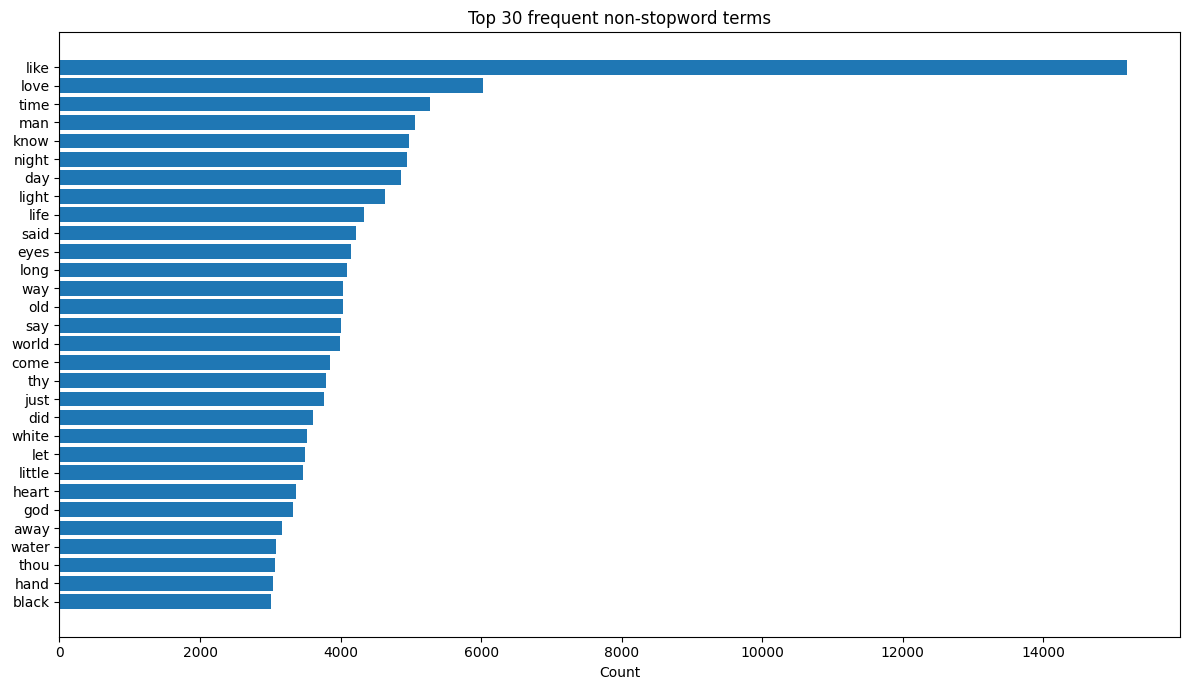

In [17]:
tags = split_tags(poems_df['tags'])
terms_df = top_frequent_terms(poems_df, top_n=30)
display(top_tags_table(poems_df, top_n=30))
display(terms_df)
if tags:
    plot_bar(Counter(tags).most_common(20), 'Top 20 tags', 'Count')
plot_bar(list(terms_df.itertuples(index=False, name=None)), 'Top 30 frequent non-stopword terms', 'Count')

## EDA Takeaways

This EDA supports the next steps of the project. The cleaned corpus is ready for NLP, the line and token counts justify tracking both token distance and line distance, the author and tag distributions explain how weak retrieval pairs can be built, and the vocabulary exploration motivates using noun chunks plus TF-IDF rather than raw word frequency alone.
